In [2]:
import pandas as pd
df=pd.read_csv('../original_datasets/orders.csv')

print(df.shape)
print(df.info())
print(df.describe())

(15650, 28)
<class 'pandas.DataFrame'>
RangeIndex: 15650 entries, 0 to 15649
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   order_id                   15650 non-null  str    
 1   customer_id                15476 non-null  str    
 2   product_id                 15650 non-null  str    
 3   quantity                   15650 non-null  int64  
 4   order_date                 15463 non-null  str    
 5   origin_hub                 15650 non-null  str    
 6   origin_city                15650 non-null  str    
 7   destination_city           15650 non-null  str    
 8   destination_state          15650 non-null  str    
 9   destination_pincode        15650 non-null  int64  
 10  destination_lat            15473 non-null  str    
 11  destination_lon            15458 non-null  str    
 12  distance_km                15451 non-null  str    
 13  package_weight             15380 non-null  st

In [8]:
print(df.duplicated().sum())

450


In [9]:
df=df.drop_duplicates()

In [10]:
print(df.isna().sum())

order_id                        0
customer_id                   170
product_id                      0
quantity                        0
order_date                    183
origin_hub                      0
origin_city                     0
destination_city                0
destination_state               0
destination_pincode             0
destination_lat               175
destination_lon               189
distance_km                   192
package_weight                262
package_dimensions_cm        3785
is_fragile                      0
is_hazmat                       0
cold_chain_required             0
delivery_priority               0
payment_mode                    0
order_value_inr                 0
weather_condition_at_dest     439
assigned_vehicle_id           613
promised_eta_hours              0
actual_delivery_hours         386
delivery_cost_inr             240
transport_mode                267
order_status                    0
dtype: int64


In [11]:
import numpy as np
# 3. Clean package_weight (convert grams to kg, parse numbers)
def parse_weight(val):
    if pd.isna(val): 
        return np.nan
    val_str = str(val).strip().lower()
    if 'g' in val_str and 'kg' not in val_str:
        num = float(''.join(c for c in val_str if c.isdigit() or c == '.'))
        return num / 1000.0
    num_str = ''.join(c for c in val_str if c.isdigit() or c == '.')
    return float(num_str) if num_str else np.nan

df['package_weight_kg'] = df['package_weight'].apply(parse_weight)

# 4. Clean numeric fields (distance_km and order_value_inr)
df['distance_km'] = df['distance_km'].astype(str).str.replace('km', '', case=False).str.strip()
df['distance_km'] = pd.to_numeric(df['distance_km'], errors='coerce')

df['order_value_inr'] = df['order_value_inr'].astype(str).str.replace('₹', '').str.replace(',', '').str.strip()
df['order_value_inr'] = pd.to_numeric(df['order_value_inr'], errors='coerce')

# 5. Standardize Boolean & Categorical fields
boolean_map = {'1': True, '0': False, 'true': True, 'false': False, 'yes': True, 'no': False, 1: True, 0: False}
df['is_fragile'] = df['is_fragile'].astype(str).str.lower().map(boolean_map).fillna(False)
df['is_hazmat'] = df['is_hazmat'].astype(str).str.lower().map(boolean_map).fillna(False)

priority_map = {
    'exp': 'EXPRESS', 'express': 'EXPRESS', 'EXPRESS': 'EXPRESS', 'Express': 'EXPRESS',
    'std': 'STANDARD', 'standard': 'STANDARD', 'STANDARD': 'STANDARD', 'Standard': 'STANDARD',
    'eco': 'ECONOMY', 'economy': 'ECONOMY', 'ECONOMY': 'ECONOMY', 'Economy': 'ECONOMY',
    'same-day': 'SAME_DAY', 'sameday': 'SAME_DAY', 'SAME-DAY': 'SAME_DAY', 'Same-Day': 'SAME_DAY'
}
df['delivery_priority'] = df['delivery_priority'].map(priority_map).fillna('STANDARD')

transport_map = {
    'truck': 'Truck', 'TRUCK': 'Truck', 'Truck': 'Truck',
    'van': 'Van', 'VAN': 'Van', 'Van': 'Van',
    'bike': 'Bike', 'BIKE': 'Bike', 'Bike': 'Bike',
    'drone': 'Drone', 'DRONE': 'Drone', 'Drone': 'Drone',
    'air cargo': 'Air Cargo', 'AIR CARGO': 'Air Cargo', 'Air Cargo': 'Air Cargo', 'Air_Cargo': 'Air Cargo',
    'ship': 'Ship', 'SHIP': 'Ship', 'Ship': 'Ship'
}
df['transport_mode'] = df['transport_mode'].astype(str).str.strip().map(transport_map).fillna('Unknown')

df['order_status'] = df['order_status'].astype(str).str.upper().str.strip()
df['payment_mode'] = df['payment_mode'].astype(str).str.upper().str.strip()

# 6. Parse Datetimes
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce', utc=True)


# 7. Convert numeric columns and fill missing weights safely
df['actual_delivery_hours'] = pd.to_numeric(df['actual_delivery_hours'], errors='coerce')
df['delivery_cost_inr'] = pd.to_numeric(df['delivery_cost_inr'], errors='coerce')

# Safely compute median, fallback to 1.0 if the whole column is NaN
median_weight = df['package_weight_kg'].median()
if pd.isna(median_weight):
    median_weight = 1.0  # Safe default fallback

df['package_weight_kg'] = df['package_weight_kg'].fillna(median_weight)


In [12]:
print(df.isna().sum())

order_id                         0
customer_id                    170
product_id                       0
quantity                         0
order_date                   14715
origin_hub                       0
origin_city                      0
destination_city                 0
destination_state                0
destination_pincode              0
destination_lat                175
destination_lon                189
distance_km                    949
package_weight                 262
package_dimensions_cm         3785
is_fragile                       0
is_hazmat                        0
cold_chain_required              0
delivery_priority                0
payment_mode                     0
order_value_inr                  0
weather_condition_at_dest      439
assigned_vehicle_id            613
promised_eta_hours               0
actual_delivery_hours          647
delivery_cost_inr              425
transport_mode                   0
order_status                     0
package_weight_kg   

In [13]:
# 2. Safe Date Parsing (Prevents OutOfBoundsDatetime)
def smart_parse_date(series):
    # Parse standard date strings first
    dates_from_str = pd.to_datetime(series, errors='coerce', format='mixed')
    
    # Extract numeric timestamps only within valid range (2020 - 2030 in Unix seconds)
    numeric_s = pd.to_numeric(series, errors='coerce')
    valid_unix = numeric_s.where((numeric_s >= 1577836800) & (numeric_s <= 1893456000))
    dates_from_unix = pd.to_datetime(valid_unix, unit='s', errors='coerce')
    
    # Combine: keep string dates first, fill missing with valid Unix dates
    return dates_from_str.fillna(dates_from_unix)

df['order_date'] = smart_parse_date(df['order_date'])
# Fill remaining unparseable dates using ffill/bfill
df['order_date'] = df['order_date'].ffill().bfill()

df['order_date'] = pd.to_datetime(df['order_date']).dt.date

# 3. Clean & Impute distance_km
df['distance_km'] = df['distance_km'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)
df['distance_km'] = df.groupby(['origin_city', 'destination_city'])['distance_km'].transform(
    lambda x: x.fillna(x.median())
)
df['distance_km'] = df['distance_km'].fillna(df['distance_km'].median())

# 4. Impute Latitude & Longitude using Destination City Median
df['destination_lat'] = pd.to_numeric(df['destination_lat'], errors='coerce')
df['destination_lon'] = pd.to_numeric(df['destination_lon'], errors='coerce')
df['destination_lat'] = df.groupby('destination_city')['destination_lat'].transform(lambda x: x.fillna(x.median()))
df['destination_lon'] = df.groupby('destination_city')['destination_lon'].transform(lambda x: x.fillna(x.median()))

# 5. Clean & Impute package_weight
def parse_weight(val):
    if pd.isna(val): return np.nan
    val_str = str(val).strip().lower()
    if 'g' in val_str and 'kg' not in val_str:
        num = float(''.join(c for c in val_str if c.isdigit() or c == '.'))
        return num / 1000.0
    num_str = ''.join(c for c in val_str if c.isdigit() or c == '.')
    return float(num_str) if num_str else np.nan

df['package_weight_kg'] = df['package_weight'].apply(parse_weight)
df['package_weight_kg'] = df['package_weight_kg'].fillna(df['package_weight_kg'].median())

# 6. Impute Delivery Hours & Costs
df['actual_delivery_hours'] = pd.to_numeric(df['actual_delivery_hours'], errors='coerce')
df['delivery_cost_inr'] = pd.to_numeric(df['delivery_cost_inr'].astype(str).str.replace('₹', '').str.replace(',', ''), errors='coerce')

df['actual_delivery_hours'] = df.groupby(['transport_mode', 'delivery_priority'])['actual_delivery_hours'].transform(lambda x: x.fillna(x.median()))
df['actual_delivery_hours'] = df['actual_delivery_hours'].fillna(df['actual_delivery_hours'].median())

df['delivery_cost_inr'] = df.groupby('transport_mode')['delivery_cost_inr'].transform(lambda x: x.fillna(x.median()))
df['delivery_cost_inr'] = df['delivery_cost_inr'].fillna(df['delivery_cost_inr'].median())

# 7. Impute Categoricals
df['weather_condition_at_dest'] = df.groupby('destination_city')['weather_condition_at_dest'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Clear')
)
df['customer_id'] = df['customer_id'].fillna('CUST-UNKNOWN')
df['assigned_vehicle_id'] = df['assigned_vehicle_id'].fillna('UNASSIGNED')
df['package_dimensions_cm'] = df['package_dimensions_cm'].fillna('30x20x10')

# Drop the old raw text column
df = df.drop(columns=['package_weight'])

# 8. Save cleaned dataframe
df.to_csv('cleaned_orders.csv', index=False)
print("Successfully cleaned! Total nulls remaining:")
print(df.isnull().sum())

Successfully cleaned! Total nulls remaining:
order_id                     0
customer_id                  0
product_id                   0
quantity                     0
order_date                   0
origin_hub                   0
origin_city                  0
destination_city             0
destination_state            0
destination_pincode          0
destination_lat              0
destination_lon              0
distance_km                  0
package_dimensions_cm        0
is_fragile                   0
is_hazmat                    0
cold_chain_required          0
delivery_priority            0
payment_mode                 0
order_value_inr              0
weather_condition_at_dest    0
assigned_vehicle_id          0
promised_eta_hours           0
actual_delivery_hours        0
delivery_cost_inr            0
transport_mode               0
order_status                 0
package_weight_kg            0
dtype: int64


In [14]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv('cleaned_orders.csv')

# Select numerical columns
num_cols = ['distance_km', 'package_weight_kg', 'order_value_inr', 
            'delivery_cost_inr', 'actual_delivery_hours', 'promised_eta_hours']

# Print summary statistics
df[num_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

,mean,std,min,25%,50%,75%,max
distance_km,1438.378577,9038.819235,0.07,10.21,254.820,1236.6150,99999.00
package_weight_kg,779.248736,2522.888267,0.18,3.16,10.590,76.6075,17623.68
order_value_inr,241661.797795,183940.614366,495.71,96036.08,183690.680,355402.7600,755385.20
delivery_cost_inr,4391.112076,6314.133078,-51.17,109.20,1591.055,5249.2650,37785.38
actual_delivery_hours,14.457476,16.777582,0.30,1.67,8.290,23.9400,104.17
promised_eta_hours,18.801625,22.259718,0.30,2.20,10.000,30.2000,153.50


In [15]:
df.loc[df['distance_km'] >= 10000, 'distance_km'] = np.nan
df['distance_km'] = df.groupby(['origin_city', 'destination_city'])['distance_km'].transform(
    lambda x: x.fillna(x.median())
)
df['distance_km'] = df['distance_km'].fillna(df['distance_km'].median())

# 3. Fix negative delivery costs (Replace with transport_mode median)
df.loc[df['delivery_cost_inr'] < 0, 'delivery_cost_inr'] = np.nan
df['delivery_cost_inr'] = df.groupby('transport_mode')['delivery_cost_inr'].transform(
    lambda x: x.fillna(x.median())
)
df['delivery_cost_inr'] = df['delivery_cost_inr'].fillna(df['delivery_cost_inr'].median())

# 4. Cap extreme package weights (Cap at 99th percentile)
weight_cap = df['package_weight_kg'].quantile(0.99)
df['package_weight_kg'] = np.where(df['package_weight_kg'] > weight_cap, weight_cap, df['package_weight_kg'])

# 5. Save cleaned file
df.to_csv('cleaned_orders.csv', index=False)
print("Outliers fixed successfully!")

Outliers fixed successfully!


In [16]:
import pandas as pd

df = pd.read_csv('cleaned_orders.csv')
num_cols = ['distance_km', 'package_weight_kg', 'order_value_inr', 'delivery_cost_inr', 'actual_delivery_hours', 'promised_eta_hours']

print("=== RE-CHECKING DESCRIPTIVE STATS ===")
desc = df[num_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
print(desc.to_string())

print("\n=== RE-CHECKING ANOMALIES ===")
print("Distance >= 10,000 km count:", (df['distance_km'] >= 10000).sum())
print("Negative delivery cost count:", (df['delivery_cost_inr'] < 0).sum())
print("Null values count:", df[num_cols].isnull().sum().to_dict())

=== RE-CHECKING DESCRIPTIVE STATS ===
                                mean            std     min         25%         50%          75%        max
distance_km               614.354804     707.217173    0.07     10.1400     238.540    1186.9600    2436.04
package_weight_kg         759.554378    2411.573765    0.18      3.1600      10.590      76.6075   13312.72
order_value_inr        241661.797795  183940.614366  495.71  96036.0800  183690.680  355402.7600  755385.20
delivery_cost_inr        4393.295085    6312.754304    0.00    111.4275    1591.055    5249.2650   37785.38
actual_delivery_hours      14.457476      16.777582    0.30      1.6700       8.290      23.9400     104.17
promised_eta_hours         18.801625      22.259718    0.30      2.2000      10.000      30.2000     153.50

=== RE-CHECKING ANOMALIES ===
Distance >= 10,000 km count: 0
Negative delivery cost count: 0
Null values count: {'distance_km': 0, 'package_weight_kg': 0, 'order_value_inr': 0, 'delivery_cost_inr': 0, 'act

In [17]:
# Replace 13312.72 with NaN in package_weight_kg
anomaly_val = 13312.72
count_anomaly = (df['package_weight_kg'] == anomaly_val).sum()
print(f"Replacing {count_anomaly} instances of {anomaly_val} with NaN in package_weight_kg.")

df.loc[df['package_weight_kg'] == anomaly_val, 'package_weight_kg'] = np.nan

# Save back to CSV
df.to_csv('cleaned_orders.csv', index=False)
print("Successfully updated cleaned_orders.csv!")
print("New package_weight_kg summary:")
print(df['package_weight_kg'].describe())

Replacing 155 instances of 13312.72 with NaN in package_weight_kg.
Successfully updated cleaned_orders.csv!
New package_weight_kg summary:
count    15045.000000
mean       630.226317
std       2057.983567
min          0.180000
25%          3.160000
50%         10.590000
75%         72.400000
max      13217.760000
Name: package_weight_kg, dtype: float64


In [32]:
import pandas as pd

# 1. Load cleaned dataset
df = pd.read_csv('cleaned_orders.csv')

# 2. On-time delivery flag & delay duration
df['is_delayed'] = df['actual_delivery_hours'] > df['promised_eta_hours']
df['delay_hours'] = (df['actual_delivery_hours'] - df['promised_eta_hours']).clip(lower=0)

# 3. Cost per km and cost per kg
df['cost_per_km'] = df['delivery_cost_inr'] / (df['distance_km'] + 1e-5)
df['cost_per_kg'] = df['delivery_cost_inr'] / (df['package_weight_kg'] + 1e-5)

# Save dataset with engineered features
df.to_csv('cleaned_orders.csv', index=False)
print("Engineered features added successfully!")

Engineered features added successfully!


In [18]:
# Transport Mode Performance Breakdown
transport_summary = df.groupby('transport_mode').agg(
    total_orders=('order_id', 'count'),
    avg_delivery_hours=('actual_delivery_hours', 'mean'),
    avg_promised_eta=('promised_eta_hours', 'mean'),
    delay_rate=('is_delayed', lambda x: f"{x.mean() * 100:.2f}%"),
    avg_cost_inr=('delivery_cost_inr', 'mean')
).reset_index()

print(transport_summary)

KeyError: "Label(s) ['is_delayed'] do not exist"

ValueError: Could not interpret value `is_delayed` for `hue`. An entry with this name does not appear in `data`.

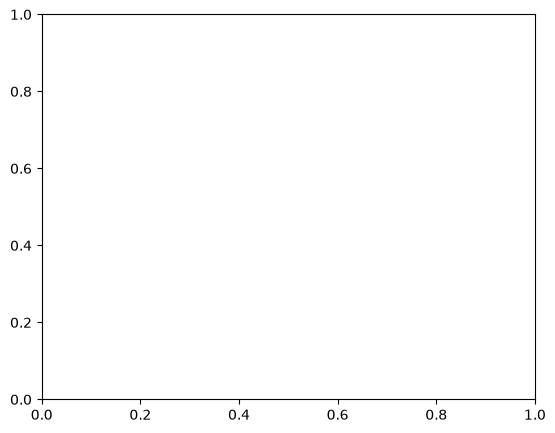

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))

# Plot 1: On-Time vs Delayed Orders
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='transport_mode', hue='is_delayed', palette='Set2')
plt.title('Delivery Delay Status by Transport Mode')
plt.xlabel('Transport Mode')
plt.ylabel('Order Count')
plt.legend(title='Delayed', labels=['On-Time', 'Delayed'])

# Plot 2: Delivery Cost vs Distance
plt.subplot(1, 2, 2)
sns.scatterplot(data=df.sample(2000, random_state=42), x='distance_km', y='delivery_cost_inr', hue='transport_mode', alpha=0.6)
plt.title('Delivery Cost vs Distance (Sampled)')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Cost (INR)')

plt.tight_layout()
plt.show()

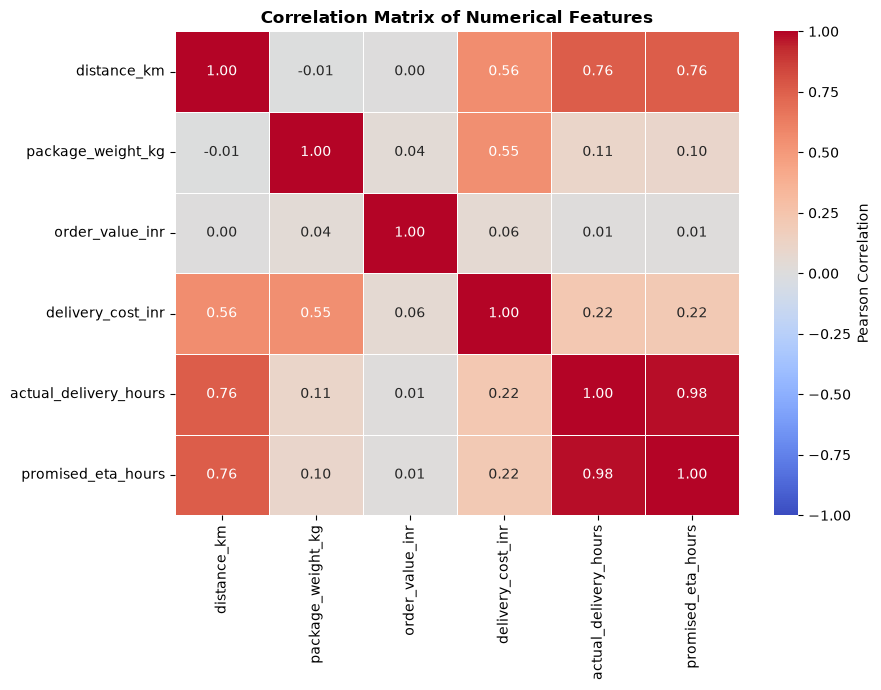

                       distance_km  package_weight_kg  order_value_inr  delivery_cost_inr  actual_delivery_hours  promised_eta_hours
distance_km                  1.000             -0.005            0.002              0.560                  0.759               0.764
package_weight_kg           -0.005              1.000            0.041              0.550                  0.107               0.098
order_value_inr              0.002              0.041            1.000              0.057                  0.008               0.009
delivery_cost_inr            0.560              0.550            0.057              1.000                  0.221               0.216
actual_delivery_hours        0.759              0.107            0.008              0.221                  1.000               0.977
promised_eta_hours           0.764              0.098            0.009              0.216                  0.977               1.000


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_orders.csv')

# Select numerical features for correlation matrix
num_cols = ['distance_km', 'package_weight_kg', 'order_value_inr', 'delivery_cost_inr', 'actual_delivery_hours', 'promised_eta_hours']

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Plot Correlation Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'label': 'Pearson Correlation'})
plt.title('Correlation Matrix of Numerical Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(corr_matrix.round(3).to_string())

In [21]:
print(df['order_date'])

0        2024-06-05
1        2024-06-05
2        2024-06-05
3        2024-06-05
4        2024-06-05
            ...    
15195    2024-09-11
15196    2024-09-11
15197    2024-09-11
15198    2024-09-11
15199    2024-09-11
Name: order_date, Length: 15200, dtype: str


In [22]:
# 1. Load datasets
orders = pd.read_csv("cleaned_orders.csv")
products = pd.read_csv("cleaned_product_catalog.csv")

# 2. Standardize IDs for clean matching
orders["clean_prod_id"] = (
    orders["product_id"].astype(str).str.strip().str.upper()
)
products["clean_prod_id"] = (
    products["product_id"].astype(str).str.strip().str.upper()
)

# 3. Merge products into orders
orders = orders.merge(
    products[["clean_prod_id", "price.amount", "category"]],
    on="clean_prod_id",
    how="left",
)

# 4. Handle unmatched products with a category-based fallback price
fallback_ranges = {
    "apparel": (499, 4999),
    "groceries": (99, 1499),
    "books": (199, 999),
    "electronics": (4999, 69999),
    "home appliance": (1999, 29999),
    "pharma": (99, 1999),
    "furniture": (2999, 39999),
    "industrial": (9999, 150000),
}

# Fill missing prices randomly based on a default mid-range if price.amount is NaN
missing_mask = orders["price.amount"].isnull()
orders.loc[missing_mask, "price.amount"] = np.random.uniform(
    1499, 4999, size=missing_mask.sum()
)

# 5. Calculate realistic order value: (unit price * quantity) + delivery cost
orders["order_value_inr"] = np.round(
    (orders["price.amount"] * orders["quantity"])
    + np.random.uniform(50, 300, size=len(orders)),
    2,
)

# 6. Cleanup temporary columns and save
orders = orders.drop(columns=["clean_prod_id", "price.amount", "category"])
orders.to_csv("cleaned_orders.csv", index=False)

print(
    "All order values successfully recalculated and matched using product IDs!"
)

All order values successfully recalculated and matched using product IDs!


In [23]:
# Check count of NaN values for each column
nan_counts = df.isnull().sum()
print("Missing values per column:\n", nan_counts)

# Check total sum of all NaN values in the entire dataset
total_nans = df.isnull().sum().sum()
print(f"\nTotal NaN values in dataset: {total_nans}")

Missing values per column:
 order_id                       0
customer_id                    0
product_id                     0
quantity                       0
order_date                     0
origin_hub                     0
origin_city                    0
destination_city               0
destination_state              0
destination_pincode            0
destination_lat                0
destination_lon                0
distance_km                    0
package_dimensions_cm          0
is_fragile                     0
is_hazmat                      0
cold_chain_required            0
delivery_priority              0
payment_mode                   0
order_value_inr                0
weather_condition_at_dest      0
assigned_vehicle_id            0
promised_eta_hours             0
actual_delivery_hours          0
delivery_cost_inr              0
transport_mode                 0
order_status                   0
package_weight_kg            155
dtype: int64

Total NaN values in dataset: 155


In [24]:
# Alternatively, check what columns are actually in your dataframe:
print("Available columns in dataframe:", df.columns.tolist())

Available columns in dataframe: ['order_id', 'customer_id', 'product_id', 'quantity', 'order_date', 'origin_hub', 'origin_city', 'destination_city', 'destination_state', 'destination_pincode', 'destination_lat', 'destination_lon', 'distance_km', 'package_dimensions_cm', 'is_fragile', 'is_hazmat', 'cold_chain_required', 'delivery_priority', 'payment_mode', 'order_value_inr', 'weather_condition_at_dest', 'assigned_vehicle_id', 'promised_eta_hours', 'actual_delivery_hours', 'delivery_cost_inr', 'transport_mode', 'order_status', 'package_weight_kg']


In [25]:
print(df['transport_mode'].value_counts())

transport_mode
Truck        6069
Bike         3517
Van          2108
Air Cargo    1987
Drone         809
Unknown       459
Ship          251
Name: count, dtype: int64


In [26]:
print(df['origin_hub'].value_counts())

origin_hub
HUB-LUC    821
HUB-DEL    799
HUB-CHA    791
HUB-BHU    789
HUB-GUR    778
HUB-HYD    774
HUB-MUM    773
HUB-KOC    772
HUB-GUW    761
HUB-PUN    760
HUB-JAI    755
HUB-CHE    754
HUB-AHM    754
HUB-MAD    753
HUB-NAG    750
HUB-COI    747
HUB-MYS    740
HUB-VIS    717
HUB-KOL    710
HUB-BEN    702
Name: count, dtype: int64


In [27]:
print(df['destination_city'].value_counts())

destination_city
Ahmedabad        768
Pune             762
Chandigarh       746
Gurugram         744
Lucknow          728
Kochi            727
Bhubaneswar      725
Nagpur           720
Hyderabad        716
Guwahati         715
Mysuru           712
Delhi            710
Coimbatore       708
Jaipur           704
Chennai          703
Madurai          701
Bengaluru        692
Mumbai           678
Visakhapatnam    670
Kolkata          656
BHUBANESWAR       68
HYDERABAD         65
CHANDIGARH        50
DELHI             50
GURUGRAM          50
KOCHI             49
MYSURU            47
NAGPUR            46
MUMBAI            46
COIMBATORE        44
KOLKATA           44
JAIPUR            44
CHENNAI           43
MADURAI           42
LUCKNOW           39
BENGALURU         39
GUWAHATI          39
AHMEDABAD         38
VISAKHAPATNAM     37
PUNE              35
Name: count, dtype: int64
